In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np


In [2]:
import pandas as pd

df = pd.read_csv('yield_df.csv')
print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())

   Unnamed: 0     Area         Item  Year  hg/ha_yield  \
0           0  Albania        Maize  1990        36613   
1           1  Albania     Potatoes  1990        66667   
2           2  Albania  Rice, paddy  1990        23333   
3           3  Albania      Sorghum  1990        12500   
4           4  Albania     Soybeans  1990         7000   

   average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp  
0                         1485.0              121.0     16.37  
1                         1485.0              121.0     16.37  
2                         1485.0              121.0     16.37  
3                         1485.0              121.0     16.37  
4                         1485.0              121.0     16.37  

Shape: (28242, 8)

Columns: ['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


In [3]:
# Basic info
print(df.info())
print("\n")

# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print("\n")

# Basic statistics
print("Basic Statistics:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB
None


Missing values:
Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year   

In [4]:
# Drop useless column
df = df.drop(columns=['Unnamed: 0'])

# Rename columns to make them easier to work with
df = df.rename(columns={
    'hg/ha_yield': 'yield',
    'average_rain_fall_mm_per_year': 'rainfall_mm',
    'pesticides_tonnes': 'pesticides',
    'avg_temp': 'temperature'
})

# Since our project is about Sri Lanka context, let's filter for rice
# (most relevant crop for Sri Lanka)
df_rice = df[df['Item'] == 'Rice, paddy']

print("Rice dataset shape:", df_rice.shape)
print("\nCountries included:")
print(df_rice['Area'].unique())


Rice dataset shape: (3388, 7)

Countries included:
['Albania' 'Algeria' 'Angola' 'Argentina' 'Australia' 'Azerbaijan'
 'Bangladesh' 'Brazil' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cameroon'
 'Central African Republic' 'Chile' 'Colombia' 'Dominican Republic'
 'Ecuador' 'Egypt' 'El Salvador' 'France' 'Ghana' 'Greece' 'Guatemala'
 'Guinea' 'Guyana' 'Haiti' 'Honduras' 'Hungary' 'India' 'Indonesia' 'Iraq'
 'Italy' 'Jamaica' 'Japan' 'Kazakhstan' 'Kenya' 'Madagascar' 'Malawi'
 'Malaysia' 'Mali' 'Mauritania' 'Mauritius' 'Mexico' 'Morocco'
 'Mozambique' 'Nepal' 'Nicaragua' 'Niger' 'Pakistan' 'Papua New Guinea'
 'Peru' 'Portugal' 'Romania' 'Rwanda' 'Senegal' 'South Africa' 'Spain'
 'Sri Lanka' 'Sudan' 'Suriname' 'Tajikistan' 'Thailand' 'Turkey' 'Uganda'
 'Ukraine' 'Uruguay' 'Zambia' 'Zimbabwe']


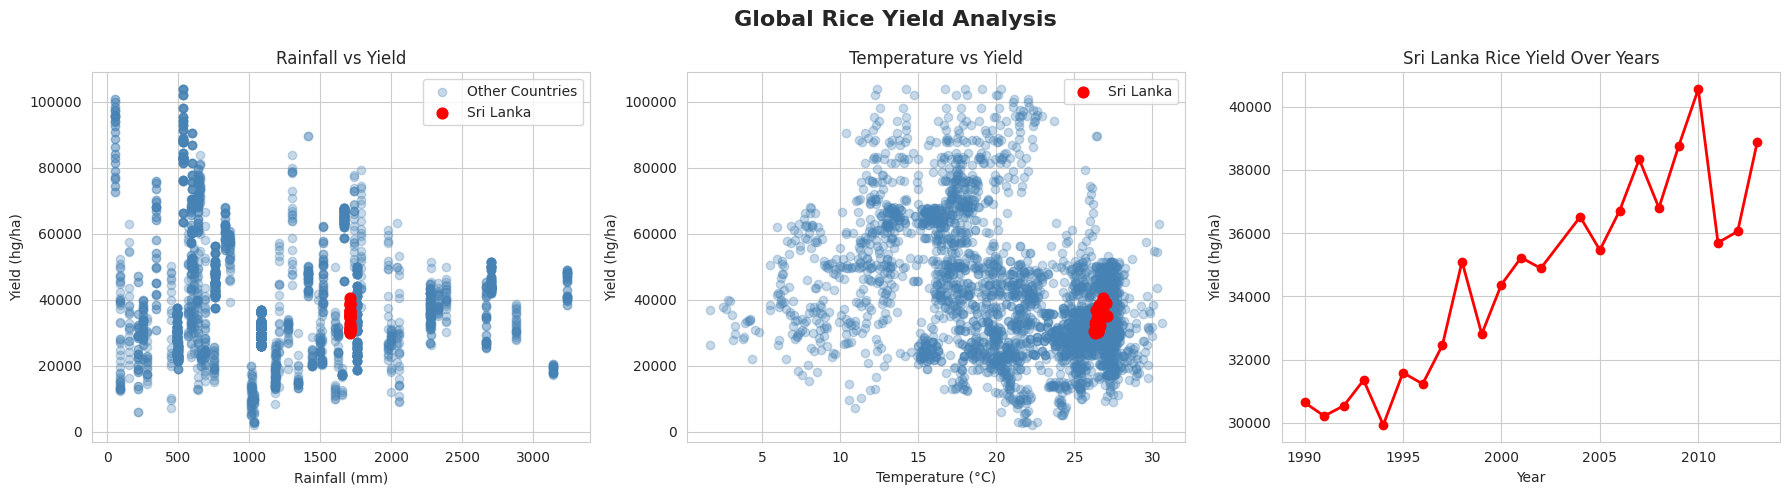

In [5]:
# Set style
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Global Rice Yield Analysis", fontsize=16, fontweight='bold')

# Chart 1 — Rainfall vs Yield
axes[0].scatter(df_rice['rainfall_mm'], df_rice['yield'], alpha=0.3, color='steelblue', label='Other Countries')
sl = df_rice[df_rice['Area'] == 'Sri Lanka']
axes[0].scatter(sl['rainfall_mm'], sl['yield'], color='red', s=60, label='Sri Lanka', zorder=5)
axes[0].set_xlabel("Rainfall (mm)")
axes[0].set_ylabel("Yield (hg/ha)")
axes[0].set_title("Rainfall vs Yield")
axes[0].legend()

# Chart 2 — Temperature vs Yield
axes[1].scatter(df_rice['temperature'], df_rice['yield'], alpha=0.3, color='steelblue')
axes[1].scatter(sl['temperature'], sl['yield'], color='red', s=60, label='Sri Lanka', zorder=5)
axes[1].set_xlabel("Temperature (°C)")
axes[1].set_ylabel("Yield (hg/ha)")
axes[1].set_title("Temperature vs Yield")
axes[1].legend()

# Chart 3 — Sri Lanka Yield Over Years
axes[2].plot(sl['Year'], sl['yield'], marker='o', color='red', linewidth=2)
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Yield (hg/ha)")
axes[2].set_title("Sri Lanka Rice Yield Over Years")

plt.tight_layout()
plt.show()

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Prepare features and target
X = df_rice[['rainfall_mm', 'temperature', 'pesticides']]
y = df_rice['yield']

# Split data — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("=" * 40)
print("        MODEL RESULTS")
print("=" * 40)
print(f"MAE:        {mae:,.2f} hg/ha")
print(f"RMSE:       {rmse:,.2f} hg/ha")
print(f"R² Score:   {r2:.4f}")
print("=" * 40)

if r2 >= 0.7:
    print("✅ Good model performance!")
elif r2 >= 0.5:
    print("⚠️ Moderate performance — can be improved")
else:
    print("❌ Low performance — needs more work")

        MODEL RESULTS
MAE:        13,316.60 hg/ha
RMSE:       17,581.04 hg/ha
R² Score:   0.1849
❌ Low performance — needs more work


In [7]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("=" * 40)
print("    RANDOM FOREST RESULTS")
print("=" * 40)
print(f"MAE:        {mae_rf:,.2f} hg/ha")
print(f"RMSE:       {rmse_rf:,.2f} hg/ha")
print(f"R² Score:   {r2_rf:.4f}")
print("=" * 40)

if r2_rf >= 0.7:
    print("✅ Good model performance!")
elif r2_rf >= 0.5:
    print("⚠️ Moderate — can be improved")
else:
    print("❌ Low performance — needs more work")

print("\n📊 Comparison:")
print(f"Linear Regression R²: {r2:.4f}")
print(f"Random Forest R²:     {r2_rf:.4f}")

    RANDOM FOREST RESULTS
MAE:        2,684.85 hg/ha
RMSE:       4,714.77 hg/ha
R² Score:   0.9414
✅ Good model performance!

📊 Comparison:
Linear Regression R²: 0.1849
Random Forest R²:     0.9414


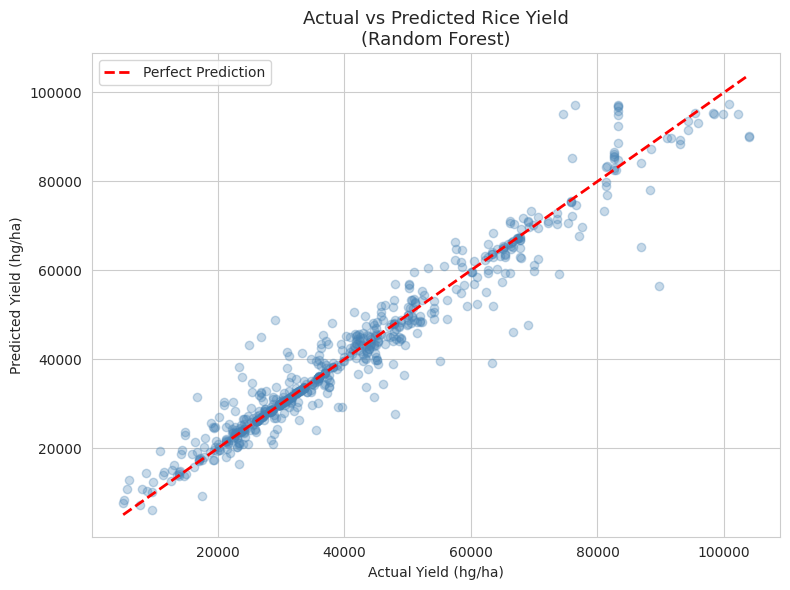

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel("Actual Yield (hg/ha)")
plt.ylabel("Predicted Yield (hg/ha)")
plt.title("Actual vs Predicted Rice Yield\n(Random Forest)", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
import numpy as np

# Let's predict for Sri Lanka's typical conditions
# Rainfall: 1800mm, Temperature: 27°C, Pesticides: 10000 tonnes

my_input = pd.DataFrame({
    'rainfall_mm': [1800],
    'temperature': [27.0],
    'pesticides': [10000]
})

prediction = rf_model.predict(my_input)

print("=" * 45)
print("       SRI LANKA RICE YIELD PREDICTION")
print("=" * 45)
print(f"  Rainfall:      1800 mm")
print(f"  Temperature:   27°C")
print(f"  Pesticides:    10,000 tonnes")
print("-" * 45)
print(f"  Predicted Yield: {prediction[0]:,.0f} hg/ha")
print(f"  Which is:        {prediction[0]/100:,.0f} kg/ha")
print(f"  Which is:        {prediction[0]/10000:,.2f} tonnes/ha")
print("=" * 45)

       SRI LANKA RICE YIELD PREDICTION
  Rainfall:      1800 mm
  Temperature:   27°C
  Pesticides:    10,000 tonnes
---------------------------------------------
  Predicted Yield: 53,168 hg/ha
  Which is:        532 kg/ha
  Which is:        5.32 tonnes/ha


In [10]:
scenarios = [
    {"name": "Drought Year",     "rainfall": 800,  "temp": 30.0, "pest": 5000},
    {"name": "Normal Year",      "rainfall": 1800, "temp": 27.0, "pest": 10000},
    {"name": "Heavy Rainfall",   "rainfall": 2800, "temp": 25.0, "pest": 15000},
    {"name": "Ideal Conditions", "rainfall": 2000, "temp": 26.0, "pest": 20000},
]

print("=" * 60)
print("         RICE YIELD PREDICTIONS — SCENARIOS")
print("=" * 60)

for s in scenarios:
    inp = pd.DataFrame({
        'rainfall_mm': [s['rainfall']],
        'temperature': [s['temp']],
        'pesticides':  [s['pest']]
    })
    pred = rf_model.predict(inp)[0]
    print(f"\n  📍 {s['name']}")
    print(f"     Rainfall: {s['rainfall']}mm | Temp: {s['temp']}°C | Pesticides: {s['pest']}")
    print(f"     Predicted Yield: {pred/10000:.2f} tonnes/ha")

print("\n" + "=" * 60)

         RICE YIELD PREDICTIONS — SCENARIOS

  📍 Drought Year
     Rainfall: 800mm | Temp: 30.0°C | Pesticides: 5000
     Predicted Yield: 4.05 tonnes/ha

  📍 Normal Year
     Rainfall: 1800mm | Temp: 27.0°C | Pesticides: 10000
     Predicted Yield: 5.32 tonnes/ha

  📍 Heavy Rainfall
     Rainfall: 2800mm | Temp: 25.0°C | Pesticides: 15000
     Predicted Yield: 3.67 tonnes/ha

  📍 Ideal Conditions
     Rainfall: 2000mm | Temp: 26.0°C | Pesticides: 20000
     Predicted Yield: 3.79 tonnes/ha

